# Primate mitochondrial phylogeny — from NCBI to tree

This notebook downloads complete **mitochondrial genomes** for apes, monkeys, modern humans and
**ancient hominins** (Neanderthals, Denisovans, Sima de los Huesos) directly from NCBI GenBank, then
builds phylogenetic trees with a standard toolchain.

**Pipeline**

| Step | Tool |
|---|---|
| Sequence retrieval | NCBI Entrez (`Bio.Entrez`) |
| Gene extraction | GenBank CDS annotations (`Bio.SeqIO`) |
| Multiple alignment | **MAFFT** — codon-aware, via protein-guided back-translation |
| Distance / NJ + bootstrap | NumPy + `Bio.Phylo.TreeConstruction` |
| Maximum likelihood | **VeryFastTree** (FastTree-compatible), GTR + Γ |
| Visualisation | Matplotlib |

**Two analyses**

1. **Deep primate tree** — 47 taxa from lemur to human, built from a codon-aware supermatrix of the
   13 mitochondrial protein-coding genes.
2. **Hominin zoom** — whole-mtDNA tree of *Homo* only (modern humans + Neanderthals + Denisovans +
   Sima de los Huesos), which resolves structure the deep tree compresses.

Everything is cached to `data/`, so re-running is cheap and only the first run touches the network.

## 0. Setup

Python packages:

```bash
pip install biopython numpy pandas matplotlib jupyter
```

External tools (macOS / Homebrew — see the README for Linux):

```bash
brew install mafft veryfasttree
```

MAFFT is required. If VeryFastTree (or `FastTree` / `iqtree`) is missing the notebook still runs —
it falls back to the neighbour-joining tree, which is pure Python.

NCBI requires a contact address for Entrez queries, so **set `NCBI_EMAIL` before running**:

```bash
export NCBI_EMAIL="you@example.com"
```

An optional `NCBI_API_KEY` raises the rate limit from 3 to 10 requests/second. The address is read
from the environment and never printed, so it stays out of the saved notebook.

In [1]:
import os, re, sys, json, shutil, inspect, subprocess, textwrap, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from Bio import Entrez, SeqIO, Phylo
from Bio.Seq import Seq
from Bio.Phylo.BaseTree import Clade, Tree
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor

from Bio import BiopythonWarning
warnings.simplefilter("ignore", BiopythonWarning)

# --- configuration -------------------------------------------------------
Entrez.email   = os.environ.get("NCBI_EMAIL", "").strip()
Entrez.api_key = os.environ.get("NCBI_API_KEY") or None

def rel(p):
    '''Path relative to the project root, so output is machine-independent.'''
    p = Path(p)
    try:
        return p.relative_to(ROOT)
    except ValueError:
        return p

ROOT    = Path.cwd()
DATA    = ROOT / "data";    DATA.mkdir(exist_ok=True)
RESULTS = ROOT / "results"; RESULTS.mkdir(exist_ok=True)
WORK    = DATA / "work";    WORK.mkdir(exist_ok=True)

# --- external tool discovery ---------------------------------------------
def which_any(*names):
    for n in names:
        p = shutil.which(n)
        if p:
            return p
    return None

MAFFT    = which_any("mafft")
FASTTREE = which_any("VeryFastTree", "veryfasttree", "FastTree", "fasttree", "FastTreeMP")
IQTREE   = which_any("iqtree3", "iqtree2", "iqtree")

print(f"python      {sys.version.split()[0]}")
print(f"mafft       {MAFFT or 'NOT FOUND  -> brew install mafft'}")
print(f"fasttree    {FASTTREE or 'not found (ML tree will be skipped)'}")
print(f"iqtree      {IQTREE or 'not found (optional)'}")
print(f"entrez      {'contact set from $NCBI_EMAIL' if Entrez.email else 'NCBI_EMAIL NOT SET'}"
      f"   api_key={'yes' if Entrez.api_key else 'no'}")

if MAFFT is None:
    raise SystemExit("MAFFT is required. Install it and restart the kernel.")
if not Entrez.email:
    raise SystemExit("NCBI requires a contact address for Entrez queries. Set it and restart:\n"
                     "    export NCBI_EMAIL='you@example.com'")

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "axes.spines.top": False, "axes.spines.right": False,
})

python      3.11.11
mafft       /usr/local/bin/mafft
fasttree    /usr/local/bin/VeryFastTree
iqtree      not found (optional)
entrez      contact set from $NCBI_EMAIL   api_key=no


## 1. Taxon sampling

Accessions are curated rather than fetched by keyword search, so the analysis is reproducible: a
search for `"Homo sapiens"[Organism] AND mitochondrion` returns tens of thousands of hits whose
composition changes week to week.

**Ancient DNA.** Eleven published ancient hominin mitochondrial genomes: seven Neanderthals spanning
Europe, the Caucasus and the Altai; three Denisovans; and the ~430,000-year-old Sima de los Huesos
femur XIII, which GenBank files under *Homo heidelbergensis*.

**Modern humans.** The reference sequence (rCRS) plus thirteen individuals from the Ingman *et al.*
(2000) global panel, chosen to span the deepest African lineages (San, Mbuti, Biaka) and the major
out-of-Africa branches.

**Apes and monkeys.** Both *Pan* species, two gorillas, both orangutans, three gibbons, six Old World
monkeys and four New World monkeys.

**Outgroups.** Tarsier and two strepsirrhines (ring-tailed lemur, slow loris) to root the tree.

Ages are approximate values from the primary publications and are shown for orientation only — no
part of the analysis uses them.

In [2]:
# accession, label, group, approximate age
TAXON_TABLE = [
    # ---- Neanderthals -------------------------------------------------
    ("AM948965.1", "Nea_Vindija33.16_Croatia",    "Neanderthal",   "~38 ka"),
    ("FM865407.1", "Nea_Feldhofer1_Germany",      "Neanderthal",   "~40 ka"),
    ("FM865409.1", "Nea_ElSidron1253_Spain",      "Neanderthal",   "~49 ka"),
    ("FM865411.1", "Nea_Mezmaiskaya1_Caucasus",   "Neanderthal",   "~65 ka"),
    ("KC879692.1", "Nea_Altai_Denisova5_Siberia", "Neanderthal",   "~90-130 ka"),
    ("KX198085.1", "Nea_GoyetQ374a_Belgium",      "Neanderthal",   "~40 ka"),
    ("KU131206.1", "Nea_DC1227_Siberia",          "Neanderthal",   "Late Pleistocene"),
    # ---- Denisovans ---------------------------------------------------
    ("FN673705.1", "Den_Denisova3_phalanx",       "Denisovan",     "~50-76 ka"),
    ("FR695060.1", "Den_Denisova4_molar",         "Denisovan",     "~50-100 ka"),
    ("KT780370.1", "Den_Denisova8_molar",         "Denisovan",     "~110-136 ka"),
    # ---- Sima de los Huesos -------------------------------------------
    ("KF683087.1", "SimaDeLosHuesos_femurXIII",   "Sima",          "~430 ka"),
    # ---- modern humans ------------------------------------------------
    ("NC_012920.1","Hsap_rCRS_reference",         "ModernHuman",   "extant"),
    ("AF347008.1", "Hsap_San",                    "ModernHuman",   "extant"),
    ("AF346998.1", "Hsap_Mbuti",                  "ModernHuman",   "extant"),
    ("AF346968.1", "Hsap_Biaka",                  "ModernHuman",   "extant"),
    ("AF347014.1", "Hsap_Yoruba",                 "ModernHuman",   "extant"),
    ("AF346995.1", "Hsap_Mandenka",               "ModernHuman",   "extant"),
    ("AF346992.1", "Hsap_Kikuyu",                 "ModernHuman",   "extant"),
    ("AF346966.1", "Hsap_AsianIndian",            "ModernHuman",   "extant"),
    ("AF346989.1", "Hsap_Japanese",               "ModernHuman",   "extant"),
    ("AF346963.1", "Hsap_AustralianAboriginal",   "ModernHuman",   "extant"),
    ("AF347004.1", "Hsap_PapuaNewGuinea_Highland","ModernHuman",   "extant"),
    ("AF347006.1", "Hsap_Saami",                  "ModernHuman",   "extant"),
    ("AF346981.1", "Hsap_French",                 "ModernHuman",   "extant"),
    ("AF347012.1", "Hsap_Warao_SouthAmerican",    "ModernHuman",   "extant"),
    # ---- great apes and gibbons ---------------------------------------
    ("NC_001643.1","Pan_troglodytes_chimpanzee",  "Ape",           "extant"),
    ("NC_001644.1","Pan_paniscus_bonobo",         "Ape",           "extant"),
    ("NC_001645.1","Gorilla_gorilla",             "Ape",           "extant"),
    ("NC_011120.1","Gorilla_gorilla_gorilla",     "Ape",           "extant"),
    ("NC_002083.1","Pongo_abelii_Sumatran",       "Ape",           "extant"),
    ("NC_001646.1","Pongo_pygmaeus_Bornean",      "Ape",           "extant"),
    ("NC_002082.1","Hylobates_lar_gibbon",        "Ape",           "extant"),
    ("NC_021957.1","Nomascus_leucogenys_gibbon",  "Ape",           "extant"),
    ("NC_014047.1","Symphalangus_syndactylus",    "Ape",           "extant"),
    # ---- Old World monkeys --------------------------------------------
    ("NC_005943.1","Macaca_mulatta_rhesus",       "OldWorldMonkey","extant"),
    ("NC_001992.1","Papio_hamadryas_baboon",      "OldWorldMonkey","extant"),
    ("NC_020006.1","Papio_anubis_baboon",         "OldWorldMonkey","extant"),
    ("NC_008066.1","Chlorocebus_sabaeus",         "OldWorldMonkey","extant"),
    ("NC_006901.1","Colobus_guereza",             "OldWorldMonkey","extant"),
    ("NC_006900.1","Trachypithecus_obscurus",     "OldWorldMonkey","extant"),
    # ---- New World monkeys --------------------------------------------
    ("NC_025586.1","Callithrix_jacchus_marmoset", "NewWorldMonkey","extant"),
    ("NC_002763.1","Cebus_albifrons_capuchin",    "NewWorldMonkey","extant"),
    ("NC_012775.1","Saimiri_sciureus_squirrel",   "NewWorldMonkey","extant"),
    ("NC_019800.1","Ateles_belzebuth_spider",     "NewWorldMonkey","extant"),
    # ---- outgroups ------------------------------------------------------
    ("NC_002811.1","Tarsius_bancanus_tarsier",    "Outgroup",      "extant"),
    ("NC_004025.1","Lemur_catta_ringtail",        "Outgroup",      "extant"),
    ("NC_002765.1","Nycticebus_coucang_loris",    "Outgroup",      "extant"),
]

taxa = pd.DataFrame(TAXON_TABLE, columns=["accession", "label", "group", "age"])
LABEL   = dict(zip(taxa.accession, taxa.label))
GROUP   = dict(zip(taxa.label,     taxa.group))
# Strepsirrhini (lemur + loris) is monophyletic and is the sister group to all other
# primates, so it roots the tree. Tarsius is coloured as an outgroup but belongs with
# the haplorhines, so it must NOT be used for rooting.
ROOT_LABELS = ["Lemur_catta_ringtail", "Nycticebus_coucang_loris"]

GROUP_COLORS = {
    "Neanderthal":    "#c0392b",
    "Denisovan":      "#8e44ad",
    "Sima":           "#d35400",
    "ModernHuman":    "#2471a3",
    "Ape":            "#1e8449",
    "OldWorldMonkey": "#117a8b",
    "NewWorldMonkey": "#7d6608",
    "Outgroup":       "#5d6d7e",
}
GROUP_ORDER = list(GROUP_COLORS)

print(f"{len(taxa)} taxa\n")
print(taxa.group.value_counts().reindex(GROUP_ORDER).to_string())
taxa.head(12)

47 taxa

group
Neanderthal        7
Denisovan          3
Sima               1
ModernHuman       14
Ape                9
OldWorldMonkey     6
NewWorldMonkey     4
Outgroup           3


,accession,label,group,age
0,AM948965.1,Nea_Vindija33.16_Croatia,Neanderthal,~38 ka
1,FM865407.1,Nea_Feldhofer1_Germany,Neanderthal,~40 ka
2,FM865409.1,Nea_ElSidron1253_Spain,Neanderthal,~49 ka
3,FM865411.1,Nea_Mezmaiskaya1_Caucasus,Neanderthal,~65 ka
4,KC879692.1,Nea_Altai_Denisova5_Siberia,Neanderthal,~90-130 ka
5,KX198085.1,Nea_GoyetQ374a_Belgium,Neanderthal,~40 ka
6,KU131206.1,Nea_DC1227_Siberia,Neanderthal,Late Pleistocene
7,FN673705.1,Den_Denisova3_phalanx,Denisovan,~50-76 ka
8,FR695060.1,Den_Denisova4_molar,Denisovan,~50-100 ka
9,KT780370.1,Den_Denisova8_molar,Denisovan,~110-136 ka


## 2. Download from NCBI

Records are fetched in GenBank format (not FASTA) because the **CDS feature annotations** are needed
to extract individual genes in the next step. The whole set is cached in a single file; delete
`data/genbank_cache.gb` to force a fresh download.

In [3]:
CACHE = DATA / "genbank_cache.gb"

def fetch_genbank(accessions, cache=CACHE, batch=20):
    '''Download GenBank records, caching to a single flat file.'''
    if cache.exists():
        recs = {r.id: r for r in SeqIO.parse(cache, "genbank")}
        if set(accessions) <= set(recs):
            print(f"cache hit: {len(recs)} records from {cache.name}")
            return recs
        print("cache incomplete -> refetching")
    with open(cache, "w") as out:
        for i in range(0, len(accessions), batch):
            chunk = accessions[i:i + batch]
            print(f"  fetching {i+1}-{i+len(chunk)} of {len(accessions)} ...")
            with Entrez.efetch(db="nuccore", id=",".join(chunk),
                               rettype="gb", retmode="text") as h:
                out.write(h.read())
    recs = {r.id: r for r in SeqIO.parse(cache, "genbank")}
    print(f"downloaded {len(recs)} records -> {rel(cache)}")
    return recs

records = fetch_genbank(list(taxa.accession))
missing = [a for a in taxa.accession if a not in records]
assert not missing, f"failed to retrieve: {missing}"

summary = pd.DataFrame([
    {"accession": a, "label": LABEL[a], "group": GROUP[LABEL[a]],
     "length_bp": len(records[a].seq),
     "organism":  records[a].annotations.get("organism", "?"),
     "n_CDS":     sum(f.type == "CDS" for f in records[a].features)}
    for a in taxa.accession
])
print(f"\ntotal sequence downloaded: {summary.length_bp.sum():,} bp")
print(f"genome length range: {summary.length_bp.min():,}-{summary.length_bp.max():,} bp")
summary.groupby("group", sort=False).agg(
    n=("accession", "size"), mean_bp=("length_bp", "mean"), min_CDS=("n_CDS", "min")
).reindex(GROUP_ORDER).round(0)

cache hit: 47 records from genbank_cache.gb

total sequence downloaded: 778,550 bp
genome length range: 16,364-17,036 bp


,n,mean_bp,min_CDS
group,,,
Neanderthal,7,16566.0,13
Denisovan,3,16571.0,13
Sima,1,16568.0,13
ModernHuman,14,16568.0,13
Ape,9,16472.0,13
OldWorldMonkey,6,16549.0,13
NewWorldMonkey,4,16522.0,13
Outgroup,3,16909.0,13


### Where the ancient genomes come from

Rather than hard-coding citations, the primary reference is read straight out of each cached GenBank
record, so it always matches the data actually being analysed.

In [4]:
rows = []
for a in taxa.loc[taxa.group.isin(["Neanderthal", "Denisovan", "Sima"]), "accession"]:
    r = records[a]
    refs = r.annotations.get("references", [])
    pub  = next((x for x in refs if x.journal and "Unpublished" not in x.journal), None)
    rows.append({
        "label":   LABEL[a],
        "accession": a,
        "title":   (pub.title[:62] + "...") if pub and len(pub.title) > 62 else (pub.title if pub else ""),
        "journal": (pub.journal[:34] if pub else ""),
    })
pd.set_option("display.max_colwidth", 70)
pd.DataFrame(rows)

,label,accession,title,journal
0,Nea_Vindija33.16_Croatia,AM948965.1,A complete Neandertal mitochondrial genome sequence determined...,"Cell 134 (3), 416-426 (2008)"
1,Nea_Feldhofer1_Germany,FM865407.1,Targeted retrieval and analysis of five Neandertal mtDNA genom...,"Science 325 (5938), 318-321 (2009)"
2,Nea_ElSidron1253_Spain,FM865409.1,Targeted retrieval and analysis of five Neandertal mtDNA genom...,"Science 325 (5938), 318-321 (2009)"
3,Nea_Mezmaiskaya1_Caucasus,FM865411.1,Targeted retrieval and analysis of five Neandertal mtDNA genom...,"Science 325 (5938), 318-321 (2009)"
4,Nea_Altai_Denisova5_Siberia,KC879692.1,Direct Submission,"Submitted (09-APR-2013) Genetics,"
5,Nea_GoyetQ374a_Belgium,KX198085.1,Neandertal cannibalism and Neandertal bones used as tools in N...,"Sci Rep 6, 29005 (2016)"
6,Nea_DC1227_Siberia,KU131206.1,"Identification of a new hominin bone from Denisova Cave, Siber...","Sci Rep 6, 23559 (2016)"
7,Den_Denisova3_phalanx,FN673705.1,The complete mitochondrial DNA genome of an unknown hominin fr...,"Nature 464 (7290), 894-897 (2010)"
8,Den_Denisova4_molar,FR695060.1,Genetic history of an archaic hominin group from Denisova Cave...,"Nature 468 (7327), 1053-1060 (2010"
9,Den_Denisova8_molar,KT780370.1,Nuclear and mitochondrial DNA sequences from two Denisovan ind...,Proc. Natl. Acad. Sci. U.S.A. 112


## 3. Why whole-genome alignment fails across the primates

The mitochondrial genome is **circular**. A linear GenBank record is an arbitrary cut through that
circle, and the cut point is *not* consistent across the database. Some records begin inside the
control region (D-loop); others begin at tRNA-Phe, roughly 570 bp further along.

Feeding these directly to an aligner asks it to reconcile sequences that are **circular permutations**
of one another. The cell below measures how each record starts, by comparing its first 60 bases with
the rCRS — a record cut at the same point is near-identical there even across species, while one cut
elsewhere looks essentially random.

In [5]:
def head_identity(seq, ref, k=60):
    '''Percent identity over the first k bases, ignoring N.

    Two records cut at the same point on the circle are near-identical here even
    across species; records cut at different points look essentially random (~25%).
    '''
    a, b = str(seq[:k]).upper(), str(ref[:k]).upper()
    ok = [(x, y) for x, y in zip(a, b) if x != "N" and y != "N"]
    return sum(x == y for x, y in ok) / max(len(ok), 1)

REF_HEAD = records["NC_012920.1"].seq          # rCRS — begins inside the control region

origins = pd.DataFrame([
    {"label": LABEL[a], "group": GROUP[LABEL[a]], "first_26bp": str(records[a].seq[:26]),
     "id_to_rCRS_start": head_identity(records[a].seq, REF_HEAD)}
    for a in taxa.accession
])
origins["same_origin"] = origins.id_to_rCRS_start > 0.70

n_same = int(origins.same_origin.sum())
print(f"records starting at the rCRS origin (control region): {n_same} / {len(origins)}")
print(f"records starting somewhere else:                      {len(origins) - n_same} / {len(origins)}\n")

for flag, title in [(True, "SAME origin as rCRS"), (False, "DIFFERENT origin")]:
    sel = origins[origins.same_origin == flag]
    print(f"--- {title} ({len(sel)}) ---")
    for _, r in sel.head(4).iterrows():
        print(f"  {r.label[:31]:31s} {r.first_26bp}  {r.id_to_rCRS_start:5.1%}")
    if len(sel) > 4:
        print(f"  ... and {len(sel) - 4} more")

print(textwrap.dedent('''
    The split does not follow taxonomy: rhesus macaque follows the human convention
    while chimpanzee — far closer to us — does not. The origin is a bookkeeping
    choice made per submission, so linear coordinates are not comparable across the
    dataset, and a whole-genome alignment would be asked to reconcile sequences that
    are circular permutations of each other.

    Fix: ignore the linear layout entirely and pull genes out by their annotations.
'''))

records starting at the rCRS origin (control region): 27 / 47
records starting somewhere else:                      20 / 47

--- SAME origin as rCRS (27) ---
  Nea_Vindija33.16_Croatia        GATCACAGGTCTATCACCCTATTAAC  100.0%
  Nea_Feldhofer1_Germany          GATCACAGGTCTATCACCCTATTAAC  100.0%
  Nea_ElSidron1253_Spain          GATCACAGGTCTATCACCCTATTAAC  100.0%
  Nea_Mezmaiskaya1_Caucasus       GATCACAGGTCTATCACCCTATTAAC  100.0%
  ... and 23 more
--- DIFFERENT origin (20) ---
  Pan_troglodytes_chimpanzee      GTTTATGTAGCTTACCCCCTCAAAGC  38.3%
  Pan_paniscus_bonobo             GTTTATGTAGCTTACCCCCTTAAAGC  38.3%
  Gorilla_gorilla                 GTTTATGTAGCTTACCTCCCCAAAGC  33.3%
  Gorilla_gorilla_gorilla         GTTTATGTAGCTTACCTCCCCAAAGC  33.3%
  ... and 16 more

The split does not follow taxonomy: rhesus macaque follows the human convention
while chimpanzee — far closer to us — does not. The origin is a bookkeeping
choice made per submission, so linear coordinates are not comparable ac

## 4. Extracting the 13 protein-coding genes

Working from CDS features solves the permutation problem outright — a gene is retrieved by its
annotation, wherever it happens to sit in the record, and `SeqFeature.extract()` handles reverse-strand
genes (ND6) and features that wrap the origin.

Two pieces of real-world messiness have to be handled:

**Inconsistent gene names.** The same gene appears as `COX1`, `cox1`, `COI` and
`"cytochrome c oxidase subunit I"` across records. `normalise_gene_name()` maps all of these onto one
vocabulary.

**Wrong `gene` qualifiers.** In `FR695060.1` (Denisova 4) the ATP6 coding sequence carries
`gene="atp8"` with `product="ATP synthase 6"` — the gene qualifier is simply wrong. The extractor
prefers `gene`, but falls back to `product` when `gene` names a slot already filled in that record.
Without this fallback Denisova 4 silently loses ATP6.

In [6]:
GENES = ["ATP6", "ATP8", "COX1", "COX2", "COX3", "CYTB",
         "ND1", "ND2", "ND3", "ND4", "ND4L", "ND5", "ND6"]
_ROMAN = {"I": "1", "II": "2", "III": "3"}

def normalise_gene_name(raw):
    '''Map any GenBank gene/product string onto a canonical mitochondrial gene symbol.'''
    if not raw:
        return None
    s = raw.strip().upper().replace("-", " ")
    m = re.search(r"CYTOCHROME C OXIDASE(?:\s+SUBUNIT)?\s+(I{1,3}|[123])", s)
    if m:
        return "COX" + _ROMAN.get(m.group(1), m.group(1))
    m = re.fullmatch(r"CO(?:X)?\s*(I{1,3}|[123])", s)
    if m:
        return "COX" + _ROMAN.get(m.group(1), m.group(1))
    if re.search(r"CYTOCHROME B", s) or re.fullmatch(r"CYT\s*B|COB", s):
        return "CYTB"
    m = re.search(r"NADH DEHYDROGENASE[, ]*(?:SUBUNIT)?\s*(4L|[1-6])", s)
    if m:
        return "ND" + m.group(1).upper()
    m = re.fullmatch(r"ND\s*(4L|[1-6])", s)
    if m:
        return "ND" + m.group(1).upper()
    m = re.search(r"ATP(?:ASE)?(?:\s+SYNTHASE)?(?:\s+F0)?(?:\s+SUBUNIT)?\s*([68])", s)
    if m:
        return "ATP" + m.group(1)
    return None

def extract_cds(record, label):
    '''Return {gene_symbol: Seq} for one record, padded to a whole number of codons.'''
    out, unmapped = {}, []
    for f in record.features:
        if f.type != "CDS":
            continue
        by_gene    = normalise_gene_name((f.qualifiers.get("gene")    or [""])[0])
        by_product = normalise_gene_name((f.qualifiers.get("product") or [""])[0])
        # prefer 'gene', but fall back to 'product' if that slot is already taken
        if by_gene and by_gene not in out:
            key = by_gene
        elif by_product and by_product not in out:
            key = by_product
        else:
            key = by_gene or by_product
        if key is None:
            unmapped.append((f.qualifiers.get("gene"), f.qualifiers.get("product")))
            continue
        s = f.extract(record.seq)
        if len(s) % 3:                      # incomplete final codon (poly-A completed in vivo)
            s = s + Seq("N" * (3 - len(s) % 3))
        out[key] = s
    return out, unmapped

genes_by_taxon, all_unmapped = {}, []
for acc in taxa.accession:
    g, u = extract_cds(records[acc], LABEL[acc])
    genes_by_taxon[LABEL[acc]] = g
    all_unmapped += [(LABEL[acc], *x) for x in u]

occupancy = pd.DataFrame(
    {g: {lab: (g in d) for lab, d in genes_by_taxon.items()} for g in GENES}
).loc[list(taxa.label)]

print(f"unmapped CDS features: {len(all_unmapped)}")
incomplete = occupancy.index[~occupancy.all(axis=1)]
if len(incomplete):
    for lab in incomplete:
        print(f"  {lab}: missing {[g for g in GENES if not occupancy.loc[lab, g]]}")
else:
    print("every taxon has all 13 protein-coding genes")

lengths = pd.Series({g: int(np.median([len(d[g]) for d in genes_by_taxon.values() if g in d]))
                     for g in GENES}, name="median_bp")
print(f"\ntotal median CDS length: {lengths.sum():,} bp")
lengths.to_frame().T

unmapped CDS features: 0
every taxon has all 13 protein-coding genes



total median CDS length: 11,403 bp


,ATP6,ATP8,COX1,COX2,COX3,CYTB,ND1,ND2,ND3,ND4,ND4L,ND5,ND6
median_bp,681,207,1542,684,786,1140,957,1044,348,1380,297,1812,525


## 5. Codon-aware alignment with MAFFT

Aligning protein-coding DNA directly lets the aligner open gaps that are not multiples of three,
producing frameshifted nonsense in the deeper comparisons. The standard fix is **translation-guided
alignment**: translate, align the proteins, then project the protein alignment back onto the codons.
Gaps are then guaranteed to fall on codon boundaries.

Two details specific to mitochondria:

- The **vertebrate mitochondrial genetic code** (NCBI translation table 2) applies, not the standard
  code: `ATA` is methionine, `TGA` is tryptophan rather than a stop, and `AGA`/`AGG` are stops.
- Stop codons are rewritten to `X` before alignment. Annotated mitochondrial CDS routinely include a
  terminal or internal stop, and `X` keeps the codon correspondence intact — MAFFT is run with
  `--anysymbol` so it accepts them.

In [7]:
def mafft_align_protein(fasta_in, fasta_out):
    cmd = [MAFFT, "--quiet", "--auto", "--anysymbol", str(fasta_in)]
    with open(fasta_out, "w") as fh:
        subprocess.run(cmd, stdout=fh, check=True)
    return {r.id: str(r.seq) for r in SeqIO.parse(fasta_out, "fasta")}

def backtranslate(protein_aln, nt_by_label, labels):
    '''Project an aligned protein alignment back onto codons (pal2nal-style).'''
    ncol = len(next(iter(protein_aln.values()))) * 3
    out = {}
    for lab in labels:
        if lab not in protein_aln:                 # gene absent -> all gaps
            out[lab] = "-" * ncol
            continue
        nt, i, buf = str(nt_by_label[lab]), 0, []
        for aa in protein_aln[lab]:
            if aa == "-":
                buf.append("---")
            else:
                buf.append(nt[i:i + 3].ljust(3, "N"))
                i += 3
        out[lab] = "".join(buf)
    return out

labels = list(taxa.label)
gene_alignments, partitions, offset = {}, [], 0

for g in GENES:
    present = {lab: s for lab, d in genes_by_taxon.items() if (s := d.get(g)) is not None}
    faa, aln_faa = WORK / f"{g}.faa", WORK / f"{g}.aln.faa"
    with open(faa, "w") as fh:
        for lab, s in present.items():
            aa = str(s.translate(table=2)).replace("*", "X")   # vertebrate mito code
            fh.write(f">{lab}\n{aa}\n")
    prot_aln = mafft_align_protein(faa, aln_faa)
    codon_aln = backtranslate(prot_aln, present, labels)
    ncol = len(next(iter(codon_aln.values())))
    gene_alignments[g] = codon_aln
    partitions.append({"gene": g, "start": offset + 1, "end": offset + ncol,
                       "length": ncol, "n_taxa": len(present)})
    offset += ncol
    print(f"  {g:5s} {len(present):2d} taxa  ->  {ncol:5,} aligned bp")

partitions = pd.DataFrame(partitions)
print(f"\nsupermatrix width: {offset:,} bp across {len(GENES)} partitions")
partitions

  ATP6  47 taxa  ->    681 aligned bp


  ATP8  47 taxa  ->    207 aligned bp


  COX1  47 taxa  ->  1,569 aligned bp


  COX2  47 taxa  ->    690 aligned bp


  COX3  47 taxa  ->    786 aligned bp


...

  ND4   47 taxa  ->  1,389 aligned bp


  ND4L  47 taxa  ->    297 aligned bp


  ND5   47 taxa  ->  1,815 aligned bp


  ND6   47 taxa  ->    540 aligned bp

supermatrix width: 11,469 bp across 13 partitions


,gene,start,end,length,n_taxa
0,ATP6,1,681,681,47
1,ATP8,682,888,207,47
2,COX1,889,2457,1569,47
3,COX2,2458,3147,690,47
4,COX3,3148,3933,786,47
5,CYTB,3934,5076,1143,47
6,ND1,5077,6033,957,47
7,ND2,6034,7080,1047,47
8,ND3,7081,7428,348,47
9,ND4,7429,8817,1389,47


In [8]:
# ---- concatenate into the supermatrix ------------------------------------
supermatrix = {lab: "".join(gene_alignments[g][lab] for g in GENES) for lab in labels}
NSITE = len(supermatrix[labels[0]])

SUPER_FASTA = RESULTS / "supermatrix_13genes_codon.fasta"
with open(SUPER_FASTA, "w") as fh:
    for lab in labels:
        fh.write(f">{lab}\n")
        for i in range(0, NSITE, 60):
            fh.write(supermatrix[lab][i:i + 60] + "\n")

# RAxML/IQ-TREE style partition file, split by codon position
with open(RESULTS / "partitions.txt", "w") as fh:
    for _, p in partitions.iterrows():
        for cp in (1, 2, 3):
            fh.write(f"DNA, {p.gene}_pos{cp} = {p.start + cp - 1}-{p.end}\\3\n")

# encode as an integer array once; every downstream distance calc reuses it
ALPHABET = np.frombuffer(b"ACGT", dtype="S1")
def encode(seqs, labs):
    arr = np.stack([np.frombuffer(seqs[l].upper().encode(), dtype="S1") for l in labs])
    code = np.full(arr.shape, 255, dtype=np.uint8)
    for i, b in enumerate(ALPHABET):
        code[arr == b] = i
    return code                                    # 255 = gap / N / ambiguous

M = encode(supermatrix, labels)
valid = M != 255
print(f"supermatrix: {len(labels)} taxa x {NSITE:,} sites")
print(f"overall occupancy: {valid.mean():.3%}")
print(f"written -> {rel(SUPER_FASTA)}")
print(f"written -> {rel(RESULTS / 'partitions.txt')}")

supermatrix: 47 taxa x 11,469 sites
overall occupancy: 99.303%
written -> results/supermatrix_13genes_codon.fasta
written -> results/partitions.txt


## 6. Alignment quality control

Two diagnostics worth running before any tree is built.

**Occupancy** — how much of each taxon's row is real sequence rather than gap. A row that is mostly
gaps carries little information and can be attracted to the wrong part of the tree.

**Substitution saturation** — third codon positions evolve fast and, over tens of millions of years,
accumulate multiple hits at the same site. Once saturated they stop tracking divergence and become
noise. Plotting third-position distance against first+second-position distance makes this visible:
a straight line means the signal is still accumulating, a plateau means it has saturated.

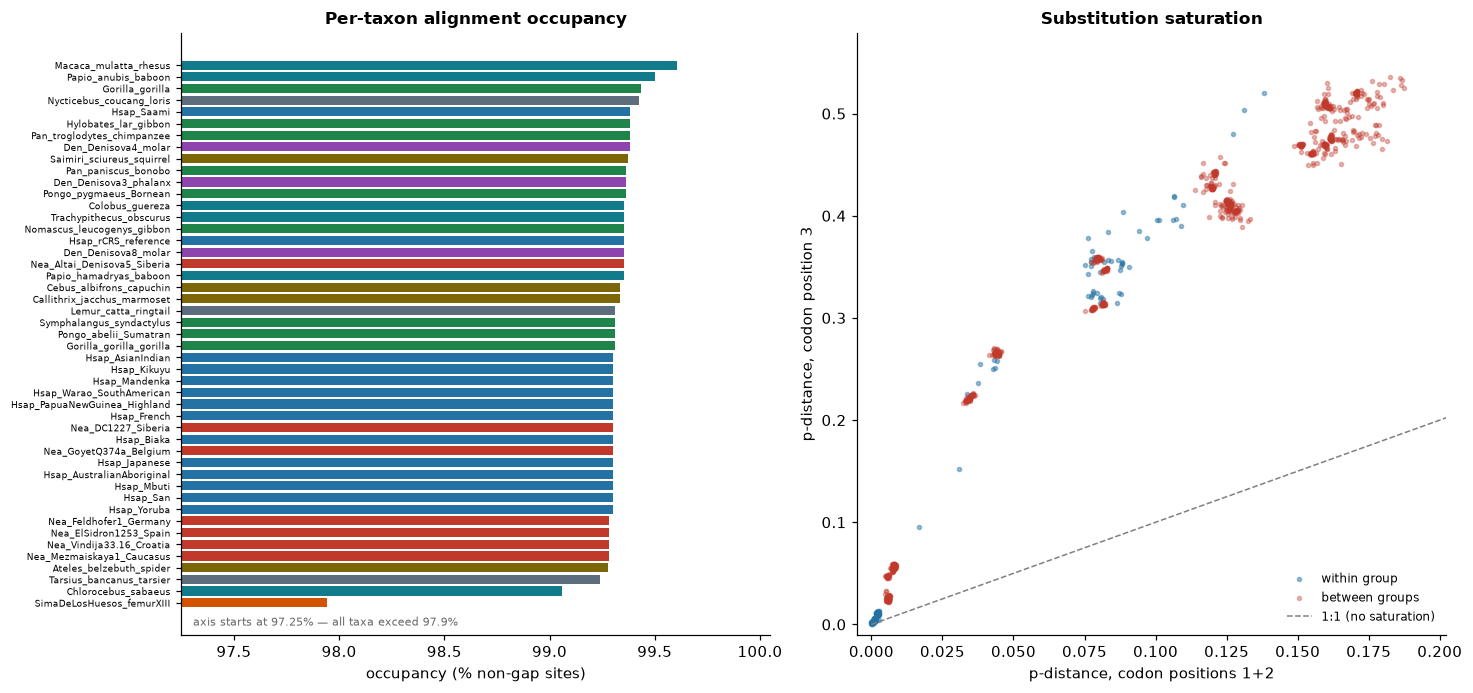

max p-distance, positions 1+2 : 0.187
max p-distance, position 3    : 0.536   (random expectation for 4 bases: 0.75)
lowest occupancy              : 97.942% (SimaDeLosHuesos_femurXIII)


In [9]:
def p_distance(code, sites=None):
    '''Pairwise uncorrected p-distance over positions where both sequences are unambiguous.'''
    C = code if sites is None else code[:, sites]
    ok = C != 255
    n = C.shape[0]
    D = np.zeros((n, n))
    for i in range(n):
        both = ok[i] & ok
        diff = (C[i] != C) & both
        cov  = both.sum(axis=1)
        D[i] = np.where(cov > 0, diff.sum(axis=1) / np.maximum(cov, 1), np.nan)
    return D

def jukes_cantor(p):
    with np.errstate(invalid="ignore", divide="ignore"):
        d = -0.75 * np.log(1.0 - (4.0 / 3.0) * p)
    return np.where(np.isfinite(d), d, np.nanmax(d[np.isfinite(d)]) * 1.5 if np.isfinite(d).any() else 1.0)

pos = np.arange(NSITE) % 3            # 0,1,2 -> codon positions 1,2,3
sites_12 = np.where(pos != 2)[0]
sites_3  = np.where(pos == 2)[0]

D_all = p_distance(M)
D_12  = p_distance(M, sites_12)
D_3   = p_distance(M, sites_3)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.4))

ax = axes[0]
occ = valid.mean(axis=1)
order = np.argsort(occ)
cols = [GROUP_COLORS[GROUP[labels[i]]] for i in order]
ax.barh(range(len(labels)), occ[order] * 100, color=cols, height=0.78)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels([labels[i] for i in order], fontsize=6)
ax.set_xlabel("occupancy (% non-gap sites)")
# every row is >97% complete, so zoom in — on a 0-100 axis the bars are indistinguishable
lo = np.floor(occ.min() * 100 * 2) / 2 - 0.25
ax.set_xlim(lo, 100.05)
ax.set_title("Per-taxon alignment occupancy", fontsize=11, weight="bold")
ax.text(0.02, 0.015, f"axis starts at {lo:.2f}% — all taxa exceed {occ.min()*100:.1f}%",
        transform=ax.transAxes, fontsize=7.5, color="0.4")

ax = axes[1]
iu = np.triu_indices(len(labels), 1)
x, y = D_12[iu], D_3[iu]
same_group = np.array([GROUP[labels[i]] == GROUP[labels[j]] for i, j in zip(*iu)])
ax.scatter(x[same_group],  y[same_group],  s=7, alpha=.45, c="#2471a3", label="within group")
ax.scatter(x[~same_group], y[~same_group], s=7, alpha=.35, c="#c0392b", label="between groups")
lim = max(x.max(), y.max()) * 1.05
ax.plot([0, lim], [0, lim], ls="--", c="0.5", lw=1, label="1:1 (no saturation)")
ax.set_xlim(-0.005, x.max() * 1.08)      # crop to the data; the 1:1 line runs off-panel
ax.set_ylim(-0.01, y.max() * 1.08)
ax.set_xlabel("p-distance, codon positions 1+2")
ax.set_ylabel("p-distance, codon position 3")
ax.set_title("Substitution saturation", fontsize=11, weight="bold")
ax.legend(fontsize=8, frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig(RESULTS / "fig1_alignment_qc.png")
plt.show()

print(f"max p-distance, positions 1+2 : {np.nanmax(D_12):.3f}")
print(f"max p-distance, position 3    : {np.nanmax(D_3):.3f}   (random expectation for 4 bases: 0.75)")
print(f"lowest occupancy              : {occ.min():.3%} ({labels[int(np.argmin(occ))]})")

Third-position distances sit far *above* the 1:1 line and then flatten: between-group comparisons pile
up around 0.5, approaching the 0.75 expected for unrelated sequences over four equally frequent bases,
while first and second positions are still climbing and reach only ~0.19. Past roughly 0.1 on the
x-axis, third positions have stopped tracking divergence — additional substitutions are landing on
sites that have already changed.

The deep-tree analysis therefore uses **first and second codon positions only**, a routine remedy for
saturation. Section 10 keeps every site, because at hominin depth nothing is saturated and the extra
signal is exactly what resolves the archaic relationships.

## 7. Distance matrix and neighbour joining

Neighbour joining with a Jukes–Cantor correction, plus non-parametric bootstrapping over alignment
columns. The distance calculation is vectorised in NumPy, which is what makes 200 bootstrap
replicates tractable in a notebook.

In [10]:
def nj_tree(dist, labs):
    '''Neighbour joining (Saitou & Nei 1987), vectorised so bootstrapping stays cheap.

    Biopython's DistanceTreeConstructor is pure Python and too slow for hundreds of
    replicates on 47 taxa; the cell below checks this implementation against it.
    '''
    n = len(labs)
    D = np.zeros((2 * n, 2 * n))
    D[:n, :n] = dist
    clades = {i: Clade(name=labs[i]) for i in range(n)}
    active, nxt = list(range(n)), n
    while len(active) > 2:
        idx = np.array(active)
        sub = D[np.ix_(idx, idx)]
        m   = len(idx)
        r   = sub.sum(axis=1)
        Q   = (m - 2) * sub - r[:, None] - r[None, :]
        np.fill_diagonal(Q, np.inf)
        a, b = np.unravel_index(np.argmin(Q), Q.shape)
        dab  = sub[a, b]
        la   = 0.5 * dab + (r[a] - r[b]) / (2 * (m - 2))
        ia, ib = int(idx[a]), int(idx[b])
        ca, cb = clades.pop(ia), clades.pop(ib)
        ca.branch_length = float(max(la, 0.0))
        cb.branch_length = float(max(dab - la, 0.0))
        newd = 0.5 * (sub[a] + sub[b] - dab)
        active.remove(ia); active.remove(ib)
        for k, ik in enumerate(idx):
            ik = int(ik)
            if ik in (ia, ib):
                continue
            D[nxt, ik] = D[ik, nxt] = max(float(newd[k]), 0.0)
        clades[nxt] = Clade(clades=[ca, cb])
        active.append(nxt); nxt += 1
    i, j = active
    clades[i].branch_length = float(max(D[i, j], 0.0))
    clades[j].branch_length = 0.0
    return Tree(root=Clade(clades=[clades[i], clades[j]]), rooted=False)

def nj_tree_biopython(dist, labs):
    '''Reference implementation, used once to validate nj_tree().'''
    dm = DistanceMatrix(list(labs),
                        [[float(dist[i][j]) for j in range(i + 1)] for i in range(len(labs))])
    return DistanceTreeConstructor().nj(dm)

def clade_set(tree, labs):
    '''Set of bipartitions (as frozensets of tip names) present in a tree.'''
    allt = set(labs)
    out = set()
    for cl in tree.get_nonterminals():
        tips = frozenset(t.name for t in cl.get_terminals())
        if 1 < len(tips) < len(allt):
            out.add(min(tips, frozenset(allt - tips), key=lambda s: (len(s), sorted(s))))
    return out

def annotate_support(tree, labs, support):
    '''Write bootstrap percentages onto internal nodes.

    The root and any single-child nodes define no bipartition, so they are left
    unannotated rather than being given a meaningless value.
    '''
    n = len(labs)
    for cl in tree.get_nonterminals():
        tips = frozenset(t.name for t in cl.get_terminals())
        if not (1 < len(tips) < n):
            cl.confidence = None
            continue
        key = min(tips, frozenset(set(labs) - tips), key=lambda s: (len(s), sorted(s)))
        v = support.get(key)
        cl.confidence = round(100 * v) if v is not None else None
    return tree

def bootstrap_support(code, labs, ref_tree, n_rep=200, seed=0):
    rng = np.random.default_rng(seed)
    ref = clade_set(ref_tree, labs)
    counts = defaultdict(int)
    nsite = code.shape[1]
    for r in range(n_rep):
        idx = rng.integers(0, nsite, nsite)
        d = jukes_cantor(p_distance(code[:, idx]))
        for c in clade_set(nj_tree(d, labs), labs):
            counts[c] += 1
        if (r + 1) % 50 == 0:
            print(f"    bootstrap {r+1}/{n_rep}")
    return {c: counts[c] / n_rep for c in ref}

M12 = M[:, sites_12]
D_nj = jukes_cantor(p_distance(M12))
tree_nj = nj_tree(D_nj, labels)

# validate the fast NJ against Biopython's reference implementation (once, on the real data)
assert clade_set(tree_nj, labels) == clade_set(nj_tree_biopython(D_nj, labels), labels), \
    "fast NJ disagrees with Biopython"
print("fast NJ matches Bio.Phylo.TreeConstruction on the observed matrix")

tree_nj.root_with_outgroup(*[{"name": n} for n in ROOT_LABELS])

print("bootstrapping neighbour joining (200 replicates, codon positions 1+2)")
support = bootstrap_support(M12, labels, tree_nj, n_rep=200)

annotate_support(tree_nj, labels, support)

tree_nj.ladderize(reverse=True)
Phylo.write(tree_nj, RESULTS / "tree_nj_bootstrap.nwk", "newick")
print(f"\nNJ tree written -> {rel(RESULTS / 'tree_nj_bootstrap.nwk')}")
print(f"median bootstrap support: {np.nanmedian(list(support.values()))*100:.0f}%")

fast NJ matches Bio.Phylo.TreeConstruction on the observed matrix
bootstrapping neighbour joining (200 replicates, codon positions 1+2)


    bootstrap 50/200


    bootstrap 100/200


    bootstrap 150/200


    bootstrap 200/200

NJ tree written -> results/tree_nj_bootstrap.nwk
median bootstrap support: 98%


## 8. Maximum likelihood tree

Neighbour joining collapses each sequence pair to a single number. Maximum likelihood uses every
column directly under an explicit substitution model, and is the better estimator — so it is the tree
reported as the main result.

**VeryFastTree** is used here: a parallelised reimplementation of FastTree with identical output and
command-line interface. `-gtr -gamma` requests a general time-reversible model with gamma-distributed
rate heterogeneity. Branch supports are FastTree's SH-like local supports (0–1), not bootstrap
proportions — they are computed from likelihood ratios at each internal node and are much cheaper,
though they tend to run slightly higher than bootstrap values.

In [11]:
ML_IN  = WORK / "supermatrix_pos12.fasta"
ML_OUT = RESULTS / "tree_ml_fasttree.nwk"

with open(ML_IN, "w") as fh:                    # positions 1+2 only, as decided in section 6
    for lab in labels:
        s = supermatrix[lab]
        fh.write(f">{lab}\n{''.join(s[i] for i in sites_12)}\n")

tree_ml = None
if FASTTREE:
    cmd = [FASTTREE, "-nt", "-gtr", "-gamma", "-quiet", str(ML_IN)]
    print("running:", Path(cmd[0]).name, *cmd[1:-1], rel(cmd[-1]))
    with open(ML_OUT, "w") as fh:
        proc = subprocess.run(cmd, stdout=fh, stderr=subprocess.PIPE, text=True)
    if proc.returncode == 0:
        tree_ml = Phylo.read(ML_OUT, "newick")
        tree_ml.root_with_outgroup(*[{"name": n} for n in ROOT_LABELS])
        tree_ml.ladderize(reverse=True)
        Phylo.write(tree_ml, ML_OUT, "newick")
        sup = [c.confidence for c in tree_ml.get_nonterminals()
               if c.confidence is not None]
        print(f"ML tree: {len(tree_ml.get_terminals())} tips, "
              f"median SH-like support {np.median(sup):.2f}")
        print(f"written -> {rel(ML_OUT)}")
    else:
        print("fasttree failed:\n", proc.stderr[-800:])
else:
    print("no fasttree binary — falling back to the NJ tree for the main figure")

main_tree = tree_ml if tree_ml is not None else tree_nj
MAIN_IS_ML = tree_ml is not None

running: VeryFastTree -nt -gtr -gamma -quiet data/work/supermatrix_pos12.fasta


ML tree: 47 tips, median SH-like support 1.00
written -> results/tree_ml_fasttree.nwk


## 9. Drawing the trees

Biopython can draw a tree, but not one that is easy to read at 47 tips. The renderer below lays out a
rectangular phylogram, colours tip labels by group, and prints support values only where they are
informative (support below 100%, on branches deep enough to matter).

In [12]:
def tree_coords(tree):
    '''x = root-to-node path length, y = tip order (internal nodes centred on children).'''
    xs, ys = {}, {}
    for i, t in enumerate(tree.get_terminals()):
        ys[id(t)] = float(i)
    for cl in tree.get_nonterminals(order="postorder"):
        kids = cl.clades
        ys[id(cl)] = 0.5 * (ys[id(kids[0])] + ys[id(kids[-1])])
    stack = [(tree.root, 0.0)]
    while stack:
        cl, x = stack.pop()
        xs[id(cl)] = x
        for k in cl.clades:
            stack.append((k, x + (k.branch_length or 0.0)))
    return xs, ys

def draw_tree(tree, ax, title="", show_support=True, support_scale=100,
              label_size=6.5, lw=1.0, group_of=None, colors=None, title_pad=30):
    group_of = group_of or GROUP
    colors   = colors or GROUP_COLORS
    xs, ys = tree_coords(tree)
    xmax = max(xs.values())

    for cl in tree.find_clades(order="level"):
        x1, y1 = xs[id(cl)], ys[id(cl)]
        if cl.clades:
            ykids = [ys[id(k)] for k in cl.clades]
            ax.plot([x1, x1], [min(ykids), max(ykids)], c="0.25", lw=lw, solid_capstyle="round")
        for k in cl.clades:
            ax.plot([x1, xs[id(k)]], [ys[id(k)], ys[id(k)]],
                    c="0.25", lw=lw, solid_capstyle="round")

    for t in tree.get_terminals():
        g = group_of.get(t.name, "Outgroup")
        c = colors.get(g, "0.2")
        ax.plot([xs[id(t)], xmax * 1.012], [ys[id(t)]] * 2, c="0.85", lw=0.5, ls=":", zorder=0)
        ax.scatter([xs[id(t)]], [ys[id(t)]], s=11, c=c, zorder=3, linewidths=0)
        ax.text(xmax * 1.02, ys[id(t)], t.name.replace("_", " "),
                va="center", ha="left", fontsize=label_size, color=c)

    if show_support:
        for cl in tree.get_nonterminals():
            v = cl.confidence
            if v is None or cl is tree.root:
                continue
            v = float(v)
            pct = v * 100 if support_scale == 1 else v
            if pct >= 99.5:
                continue
            ax.text(xs[id(cl)] - xmax * 0.004, ys[id(cl)] + 0.34, f"{pct:.0f}",
                    fontsize=4.8, ha="right", va="bottom", color="#b03a2e")

    ax.set_ylim(-1, len(tree.get_terminals()))
    ax.set_xlim(-xmax * 0.02, xmax * 1.34)
    ax.invert_yaxis()
    ax.set_yticks([])
    for s in ("top", "left", "right"):
        ax.spines[s].set_visible(False)
    ax.set_xlabel("substitutions per site")   # the axis is the scale; no scale bar needed
    if title:
        ax.set_title(title, fontsize=12, weight="bold", loc="left", pad=title_pad)
    return ax

def group_legend(ax, groups=GROUP_ORDER, **kw):
    from matplotlib.lines import Line2D
    h = [Line2D([], [], marker="o", ls="", color=GROUP_COLORS[g], label=g, markersize=6)
         for g in groups]
    ax.legend(handles=h, fontsize=7.5, frameon=False, **kw)

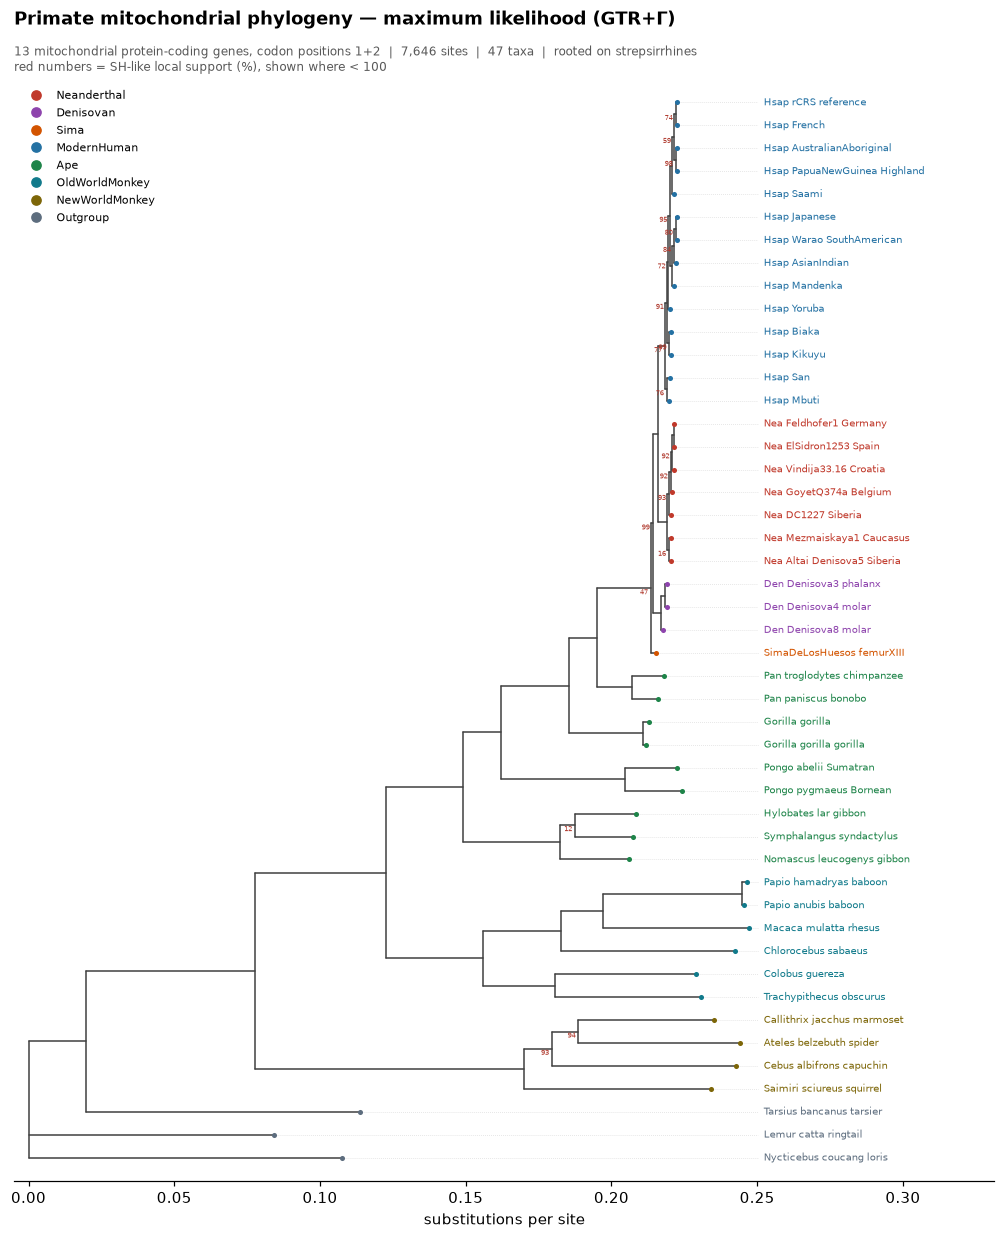

In [13]:
fig, ax = plt.subplots(figsize=(11.5, 13))
draw_tree(main_tree, ax,
          title=("Primate mitochondrial phylogeny — maximum likelihood (GTR+" + chr(915) + ")"
                 if MAIN_IS_ML else "Primate mitochondrial phylogeny — neighbour joining"),
          support_scale=1 if MAIN_IS_ML else 100, title_pad=36)
sub = ("13 mitochondrial protein-coding genes, codon positions 1+2  |  "
       f"{len(sites_12):,} sites  |  {len(labels)} taxa  |  rooted on strepsirrhines\n"
       + ("red numbers = SH-like local support (%), shown where < 100"
          if MAIN_IS_ML else "red numbers = bootstrap support (%), 200 replicates, shown where < 100"))
ax.text(0, 1.004, sub, transform=ax.transAxes, fontsize=8, color="0.35", va="bottom")
group_legend(ax, loc="upper left")
plt.savefig(RESULTS / "fig2_primate_tree_main.png")
plt.show()

### Does the tree recover the accepted primate relationships?

The tree above is an estimate; the relationships among these particular primates are, for the most
part, not in dispute. Checking the recovered topology against textbook clades is a direct test of
whether the pipeline worked.

In [14]:
def has_clade(tree, members):
    '''Is `members` a clade of this tree, tested as an unrooted bipartition?

    A rooted-clade test would report a group as absent purely because the root was
    placed inside it — rooting on the strepsirrhines, for example, splits them into
    two children of the root. Matching either the group or its complement makes the
    answer independent of root placement.
    '''
    members = frozenset(members)
    allt = frozenset(t.name for t in tree.get_terminals())
    if not members <= allt:
        return False, None
    comp = allt - members
    for cl in tree.get_nonterminals():
        tips = frozenset(t.name for t in cl.get_terminals())
        if tips == members or tips == comp:
            return True, cl.confidence
    return False, None

by_group = {g: list(taxa.loc[taxa.group == g, "label"]) for g in GROUP_ORDER}
homo_all = by_group["ModernHuman"] + by_group["Neanderthal"] + by_group["Denisovan"] + by_group["Sima"]

checks = [
    ("Homo (modern + archaic) is monophyletic",      homo_all),
    ("Modern humans form a clade",                    by_group["ModernHuman"]),
    ("Neanderthals form a clade",                     by_group["Neanderthal"]),
    ("Denisovans + Sima de los Huesos group together",by_group["Denisovan"] + by_group["Sima"]),
    ("Pan (chimpanzee + bonobo)",                     ["Pan_troglodytes_chimpanzee", "Pan_paniscus_bonobo"]),
    ("Homo + Pan",                                    homo_all + ["Pan_troglodytes_chimpanzee", "Pan_paniscus_bonobo"]),
    ("Gorilla",                                       ["Gorilla_gorilla", "Gorilla_gorilla_gorilla"]),
    ("Pongo (both orangutans)",                       ["Pongo_abelii_Sumatran", "Pongo_pygmaeus_Bornean"]),
    ("Hominidae (great apes incl. Homo)",             homo_all + [x for x in by_group["Ape"] if "gibbon" not in x and "Symphalangus" not in x]),
    ("Hylobatidae (gibbons + siamang)",               ["Hylobates_lar_gibbon", "Nomascus_leucogenys_gibbon", "Symphalangus_syndactylus"]),
    ("Hominoidea (apes + Homo)",                      homo_all + by_group["Ape"]),
    ("Cercopithecidae (Old World monkeys)",           by_group["OldWorldMonkey"]),
    ("Catarrhini (OWM + apes)",                       homo_all + by_group["Ape"] + by_group["OldWorldMonkey"]),
    ("Platyrrhini (New World monkeys)",               by_group["NewWorldMonkey"]),
    ("Anthropoidea (all monkeys + apes)",             homo_all + by_group["Ape"] + by_group["OldWorldMonkey"] + by_group["NewWorldMonkey"]),
    ("Haplorhini (tarsier + anthropoids)",            homo_all + by_group["Ape"] + by_group["OldWorldMonkey"] + by_group["NewWorldMonkey"] + ["Tarsius_bancanus_tarsier"]),
    ("Strepsirrhini (lemur + loris)",                 ["Lemur_catta_ringtail", "Nycticebus_coucang_loris"]),
]

rows = []
for name, members in checks:
    ok_ml, sup_ml = has_clade(main_tree, members)
    ok_nj, sup_nj = has_clade(tree_nj, members)
    rows.append({
        "clade": name,
        "n_tips": len(members),
        ("ML" if MAIN_IS_ML else "NJ(main)"): "yes" if ok_ml else "NO",
        "support": (f"{float(sup_ml):.2f}" if (ok_ml and sup_ml is not None and MAIN_IS_ML)
                    else (f"{float(sup_ml):.0f}%" if (ok_ml and sup_ml is not None) else "-")),
        "NJ+boot": "yes" if ok_nj else "NO",
        "NJ support": f"{float(sup_nj):.0f}%" if (ok_nj and sup_nj is not None) else "-",
    })
res = pd.DataFrame(rows)
n_ok = (res.iloc[:, 2] == "yes").sum()
print(f"{n_ok}/{len(res)} expected clades recovered in the main tree\n")
res

16/17 expected clades recovered in the main tree



,clade,n_tips,ML,support,NJ+boot,NJ support
0,Homo (modern + archaic) is monophyletic,25,yes,0.47,yes,100%
1,Modern humans form a clade,14,yes,0.77,yes,100%
2,Neanderthals form a clade,7,yes,1.00,yes,100%
3,Denisovans + Sima de los Huesos group together,4,NO,-,yes,52%
4,Pan (chimpanzee + bonobo),2,yes,1.00,yes,100%
5,Homo + Pan,27,yes,1.00,yes,100%
6,Gorilla,2,yes,1.00,yes,100%
7,Pongo (both orangutans),2,yes,1.00,yes,100%
8,Hominidae (great apes incl. Homo),31,yes,1.00,yes,100%
9,Hylobatidae (gibbons + siamang),3,yes,1.00,yes,100%


## 10. Hominin zoom — whole mitochondrial genomes

The deep tree has almost no power inside *Homo*. Restricting it to first and second codon positions
was the right call for the primate-wide comparison, but those positions barely vary among hominins —
which is why the archaic relationships there came out weakly supported. That question needs its own
analysis, at a resolution the deep tree cannot provide.

A *Homo*-focused analysis can afford to be far more sensitive: the whole 16.5 kb, control region
included, with every codon position kept. Section 6 found saturation only in the deep comparisons.

**First, the circularity problem has to be solved rather than avoided.** A useful outgroup here is
*Pan*, but chimpanzee records are cut at a different point on the circle than human ones. Since every
record annotates tRNA-Phe, each sequence can simply be **rotated to start there** — the standard
origin for vertebrate mtDNA records. This costs a few lines, puts every sequence in the same frame,
and has a useful side effect: the control region, which the human convention splits across both ends
of the record, becomes contiguous.

**Rooting on *Pan* keeps the question open.** The previous alternative — rooting on the archaic
lineages themselves — would have assumed the very relationship being tested, collapsing it into a
polytomy at the root. With *Pan* outside, where the Sima de los Huesos lineage attaches is something
the data decide.

In [15]:
def trna_phe_start(record):
    '''Offset of tRNA-Phe, the conventional origin for a vertebrate mtDNA record.'''
    for f in record.features:
        q = " ".join(f.qualifiers.get("gene", []) + f.qualifiers.get("product", [])).upper()
        if f.type in ("tRNA", "gene") and re.search(r"TRNA[- ]?PHE", q):
            return int(f.location.start)
    raise KeyError(f"no tRNA-Phe annotation in {record.id}")

def rotate_to_origin(record):
    '''Rotate a circular mtDNA record so it begins at tRNA-Phe.

    This also makes the control region contiguous at the end of the sequence,
    instead of split across both ends as it is in the human convention.
    '''
    k = trna_phe_start(record)
    return record.seq[k:] + record.seq[:k]

acc_of      = {v: k for k, v in LABEL.items()}
homo_labels = [l for l in labels if GROUP[l] in ("ModernHuman", "Neanderthal", "Denisovan", "Sima")]
OUTGROUP_B  = ["Pan_troglodytes_chimpanzee", "Pan_paniscus_bonobo"]
panel_b     = homo_labels + OUTGROUP_B

shift = {l: trna_phe_start(records[acc_of[l]]) for l in panel_b}
print(f"rotating {len(panel_b)} records to the tRNA-Phe origin")
print(f"  Homo records shift by : {sorted({shift[l] for l in homo_labels})} bp")
print(f"  Pan records shift by  : {sorted({shift[l] for l in OUTGROUP_B})} bp (already there)")
print("\nfirst 16 bp after rotation:")
for h in sorted({str(rotate_to_origin(records[acc_of[l]])[:16]) for l in panel_b}):
    print(f"    {h}")
print("  -> one landmark; the remaining differences are real substitutions")

HOMO_IN, HOMO_ALN = WORK / "hominin_rotated.fasta", WORK / "hominin_rotated.aln.fasta"
with open(HOMO_IN, "w") as fh:
    for l in panel_b:
        fh.write(f">{l}\n{str(rotate_to_origin(records[acc_of[l]]))}\n")

print("\naligning whole mitochondrial genomes with MAFFT ...")
with open(HOMO_ALN, "w") as fh:
    subprocess.run([MAFFT, "--quiet", "--auto", str(HOMO_IN)], stdout=fh, check=True)

aln_b = {r.id: str(r.seq).upper() for r in SeqIO.parse(HOMO_ALN, "fasta")}
Mb = encode(aln_b, panel_b)
Mh = Mb[np.array([panel_b.index(l) for l in homo_labels])]      # Homo rows only
print(f"alignment: {len(panel_b)} taxa x {Mb.shape[1]:,} columns "
      f"({(Mb != 255).mean():.2%} occupancy)")

Db = jukes_cantor(p_distance(Mb))
tree_h = nj_tree(Db, panel_b)
tree_h.root_with_outgroup(*[{"name": n} for n in OUTGROUP_B])
print("bootstrapping (300 replicates, whole mtDNA)")
sup_h = bootstrap_support(Mb, panel_b, tree_h, n_rep=300, seed=1)
annotate_support(tree_h, panel_b, sup_h)
tree_h.ladderize(reverse=True)

tree_h_ml = None
if FASTTREE:
    hml = RESULTS / "tree_hominin_ml.nwk"
    with open(hml, "w") as fh:
        subprocess.run([FASTTREE, "-nt", "-gtr", "-gamma", "-quiet", str(HOMO_ALN)],
                       stdout=fh, stderr=subprocess.DEVNULL, check=True)
    tree_h_ml = Phylo.read(hml, "newick")
    tree_h_ml.root_with_outgroup(*[{"name": n} for n in OUTGROUP_B])
    tree_h_ml.ladderize(reverse=True)
    Phylo.write(tree_h_ml, hml, "newick")

Phylo.write(tree_h, RESULTS / "tree_hominin_nj.nwk", "newick")
print("done")

rotating 27 records to the tRNA-Phe origin
  Homo records shift by : [572, 573, 574, 575, 576, 577, 578, 580] bp
  Pan records shift by  : [0] bp (already there)

first 16 bp after rotation:
    GTTTATGTAGCTTACC
  -> one landmark; the remaining differences are real substitutions

aligning whole mitochondrial genomes with MAFFT ...


alignment: 27 taxa x 16,598 columns (99.74% occupancy)
bootstrapping (300 replicates, whole mtDNA)


    bootstrap 50/300


    bootstrap 100/300


    bootstrap 150/300


    bootstrap 200/300


    bootstrap 250/300


    bootstrap 300/300


done


### Testing the archaic relationships

Because this tree is rooted on *Pan* rather than on any hominin, the relationships among the archaic
lineages are an outcome of the analysis rather than an assumption built into it.

In [16]:
hom_groups = {g: [l for l in homo_labels if GROUP[l] == g]
              for g in ("ModernHuman", "Neanderthal", "Denisovan", "Sima")}
hom_checks = [
    ("Modern humans",                         hom_groups["ModernHuman"]),
    ("Neanderthals",                          hom_groups["Neanderthal"]),
    ("Denisovans",                            hom_groups["Denisovan"]),
    ("Denisovans + Sima de los Huesos",       hom_groups["Denisovan"] + hom_groups["Sima"]),
    ("Sima + Neanderthals (the alternative)", hom_groups["Sima"] + hom_groups["Neanderthal"]),
    ("Modern humans + Neanderthals",          hom_groups["ModernHuman"] + hom_groups["Neanderthal"]),
    ("All Homo (vs Pan outgroup)",            homo_labels),
]
rows = []
for name, mem in hom_checks:
    ok_n, sup_n = has_clade(tree_h, mem)
    ok_m, sup_m = (has_clade(tree_h_ml, mem) if tree_h_ml is not None else (None, None))
    rows.append({"clade": name, "n_tips": len(mem),
                 "NJ": "yes" if ok_n else "no",
                 "bootstrap": f"{float(sup_n):.0f}%" if (ok_n and sup_n is not None) else "-",
                 "ML": ("yes" if ok_m else "no") if tree_h_ml is not None else "n/a",
                 "SH-like": f"{float(sup_m):.2f}" if (ok_m and sup_m is not None) else "-"})
hom_res = pd.DataFrame(rows)
hom_res

,clade,n_tips,NJ,bootstrap,ML,SH-like
0,Modern humans,14,yes,100%,yes,0.92
1,Neanderthals,7,yes,100%,yes,1.00
2,Denisovans,3,yes,100%,yes,1.00
3,Denisovans + Sima de los Huesos,4,yes,100%,yes,1.00
4,Sima + Neanderthals (the alternative),8,no,-,no,-
5,Modern humans + Neanderthals,21,yes,100%,yes,1.00
6,All Homo (vs Pan outgroup),25,yes,100%,yes,1.00


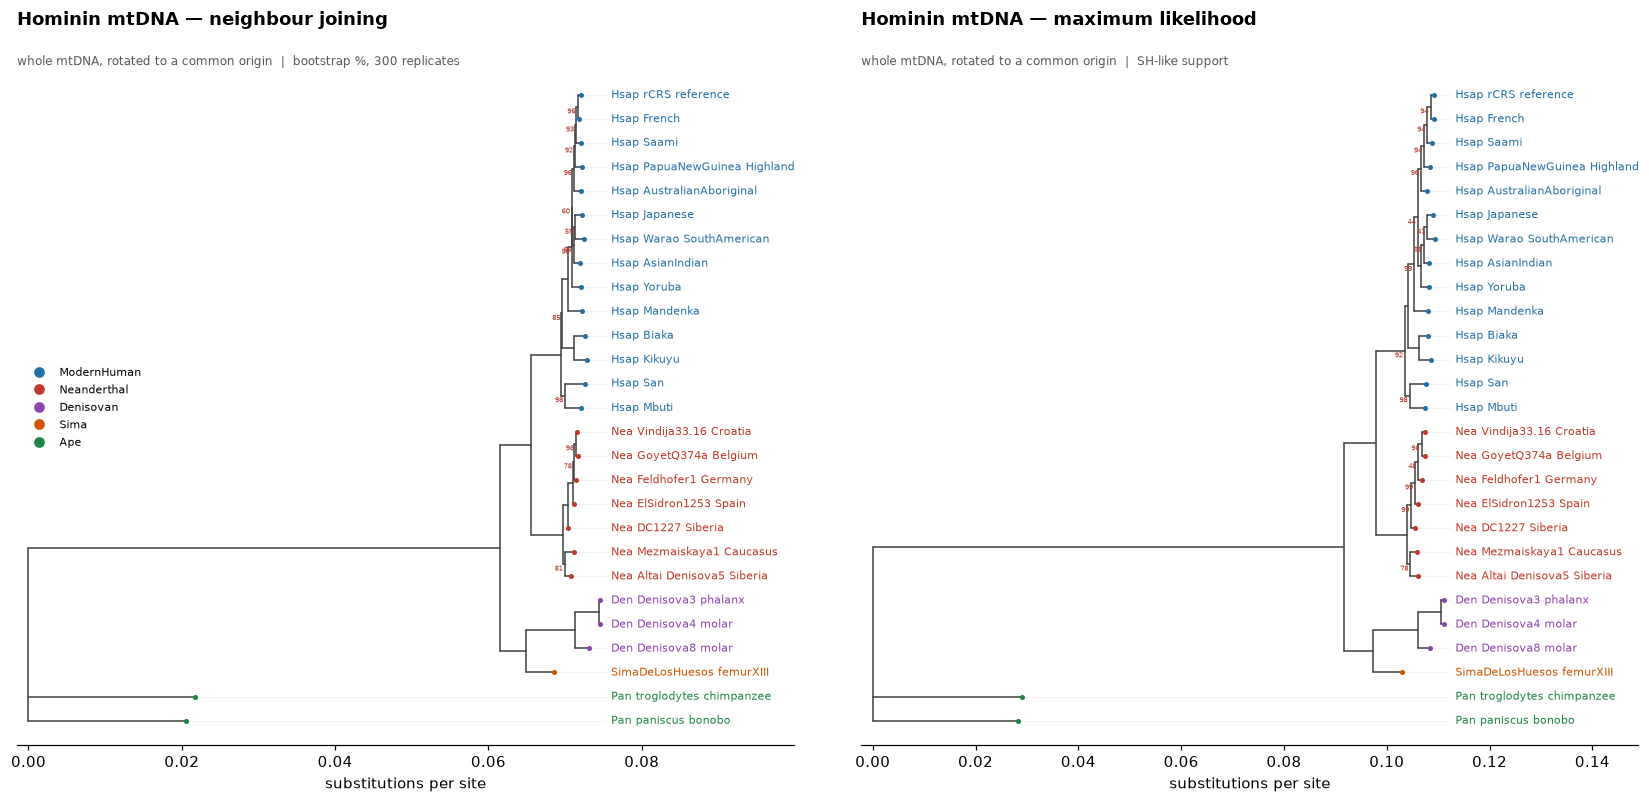

In [17]:
show_ml = tree_h_ml is not None
fig, axes = plt.subplots(1, 2 if show_ml else 1, figsize=(15.5 if show_ml else 8.5, 7.4),
                         squeeze=False)
axes = axes.ravel()

draw_tree(tree_h, axes[0], title="Hominin mtDNA — neighbour joining",
          support_scale=100, label_size=7)
axes[0].text(0, 1.004, "whole mtDNA, rotated to a common origin  |  bootstrap %, 300 replicates",
             transform=axes[0].transAxes, fontsize=8, color="0.35", va="bottom")
if show_ml:
    draw_tree(tree_h_ml, axes[1], title="Hominin mtDNA — maximum likelihood",
              support_scale=1, label_size=7)
    axes[1].text(0, 1.004, "whole mtDNA, rotated to a common origin  |  SH-like support",
                 transform=axes[1].transAxes, fontsize=8, color="0.35", va="bottom")
group_legend(axes[0], groups=["ModernHuman", "Neanderthal", "Denisovan", "Sima", "Ape"],
             loc="center left")
plt.tight_layout()
plt.savefig(RESULTS / "fig3_hominin_tree.png")
plt.show()

### Divergence within and between hominin lineages

A useful sanity check on the whole exercise: mitochondrial diversity *within* modern humans should be
small compared with the distance separating modern humans from Neanderthals, which in turn should be
small compared with the distance to Denisovans.

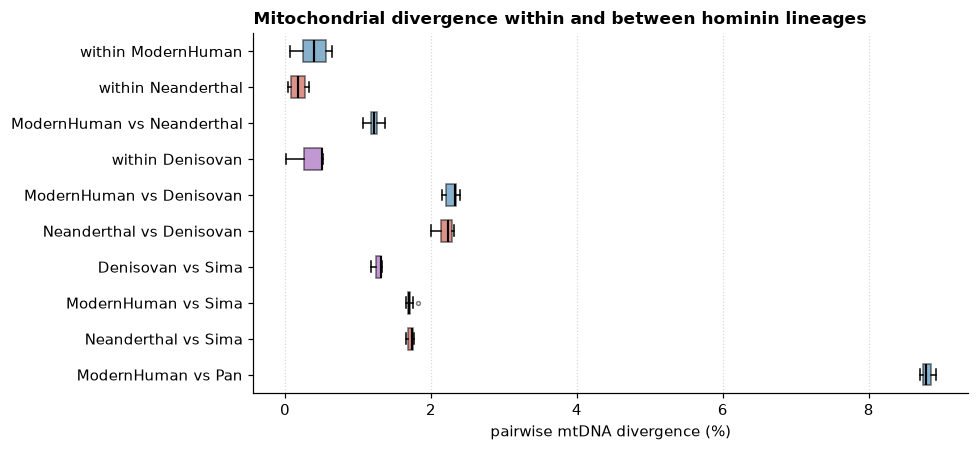

,comparison,n_pairs,mean_%,min_%,max_%
0,within ModernHuman,91,0.402,0.066,0.640
1,within Neanderthal,21,0.175,0.036,0.326
2,ModernHuman vs Neanderthal,98,1.216,1.067,1.371
3,within Denisovan,3,0.346,0.012,0.519
4,ModernHuman vs Denisovan,42,2.294,2.155,2.391
5,Neanderthal vs Denisovan,21,2.210,2.006,2.314
6,Denisovan vs Sima,3,1.274,1.184,1.325
7,ModernHuman vs Sima,14,1.711,1.662,1.816
8,Neanderthal vs Sima,7,1.722,1.656,1.767
9,ModernHuman vs Pan,28,8.801,8.699,8.915


In [18]:
idx = {l: i for i, l in enumerate(homo_labels)}
grp = {g: [idx[l] for l in homo_labels if GROUP[l] == g]
       for g in ("ModernHuman", "Neanderthal", "Denisovan", "Sima")}
# chimpanzee rows live in Mb, not Mh; append them so Pan can anchor the scale
idx_pan = [panel_b.index(l) for l in OUTGROUP_B]
Mh_pan = np.vstack([Mh, Mb[idx_pan]])
grp["Pan"] = [len(homo_labels), len(homo_labels) + 1]

Ph = p_distance(Mh_pan) * 100      # percent sequence divergence
def between(a, b):
    v = Ph[np.ix_(grp[a], grp[b])]
    if a == b:
        v = v[np.triu_indices(len(grp[a]), 1)]
    return v.ravel()

pairs = [("ModernHuman", "ModernHuman"), ("Neanderthal", "Neanderthal"),
         ("ModernHuman", "Neanderthal"), ("Denisovan", "Denisovan"),
         ("ModernHuman", "Denisovan"), ("Neanderthal", "Denisovan"),
         ("Denisovan", "Sima"), ("ModernHuman", "Sima"), ("Neanderthal", "Sima"),
         ("ModernHuman", "Pan")]

stats = pd.DataFrame([
    {"comparison": f"{a} vs {b}" if a != b else f"within {a}",
     "n_pairs": len(v := between(a, b)),
     "mean_%": round(float(np.nanmean(v)), 3),
     "min_%":  round(float(np.nanmin(v)), 3),
     "max_%":  round(float(np.nanmax(v)), 3)}
    for a, b in pairs if len(between(a, b))
])

fig, ax = plt.subplots(figsize=(9, 4.2))
data = [between(a, b) for a, b in pairs if len(between(a, b))]
names = list(stats.comparison)
# matplotlib renamed these keywords across versions; pick whichever this build accepts
_bp = inspect.signature(ax.boxplot).parameters
_horiz = {"orientation": "horizontal"} if "orientation" in _bp else {"vert": False}
bp = ax.boxplot(data, patch_artist=True, widths=.6, **_horiz,
                medianprops=dict(color="k", lw=1.4), flierprops=dict(ms=2.5, alpha=.5))
ax.set_yticks(range(1, len(names) + 1))
ax.set_yticklabels(names)
for patch, (a, b) in zip(bp["boxes"], [p for p in pairs if len(between(*p))]):
    patch.set_facecolor(GROUP_COLORS[{"Pan": "Ape"}.get(a, a)]); patch.set_alpha(.55)
ax.set_xlabel("pairwise mtDNA divergence (%)")
ax.set_title("Mitochondrial divergence within and between hominin lineages",
             fontsize=11, weight="bold", loc="left")
ax.grid(axis="x", ls=":", alpha=.5)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS / "fig4_hominin_divergence.png")
plt.show()

stats

## 11. What the trees show

**The pipeline reproduces the accepted primate phylogeny.** From public sequence and standard tools,
the deep tree recovers strepsirrhines and tarsier outside the anthropoids, New World monkeys as a
clade, Old World monkeys splitting into colobines and cercopithecines, gibbons as sister to the great
apes, and the *Pongo* → *Gorilla* → *Pan* → *Homo* series — 16 of the 17 clades checked in section 9,
almost all at full support.

**The one failure is informative.** The deep tree does not resolve Denisovans + Sima de los Huesos:
maximum likelihood misses it outright and neighbour joining recovers it at only ~52% bootstrap. Even
*Homo* itself sits at ~0.47 SH-like support there. This is not a bug — it is the cost of the
saturation fix. Dropping third codon positions was necessary to align across 65 million years of
primate evolution, but first and second positions are nearly invariant among hominins, so almost no
signal remains at that depth. The right response is not to trust the weak answer but to ask the
question with data that can answer it.

**Which the hominin analysis does.** Rooted on *Pan*, using whole rotated genomes and every site, the
archaic relationships resolve completely: Denisovans + Sima de los Huesos at **100% bootstrap and 1.00
SH-like support**, with the competing arrangement — Sima grouping with the Neanderthals — absent from
both trees. Modern humans, Neanderthals and Denisovans each form reciprocally monophyletic clades at
full support. All seven Neanderthals group together despite spanning Spain to the Altai, and no
Neanderthal sequence falls inside the modern human range or the reverse.

**Sima de los Huesos sits with the Denisovans — and that is genuinely strange.** This is the result
from Meyer *et al.* (2014). On morphology the ~430,000-year-old Sima hominins look like early
Neanderthals, and their nuclear DNA later confirmed a Neanderthal affinity — yet the *mitochondrial*
genome groups with Denisovans. The distance table makes the pattern concrete: Sima is ~1.3% divergent
from Denisovans but ~1.7% from both Neanderthals and modern humans. The gene tree and the population
tree genuinely disagree here, and the notebook reproduces that disagreement from raw sequence rather
than asserting it.

**Modern human mtDNA diversity is shallow and rooted in Africa.** The San and Mbuti sequences attach
near the base of the modern human clade with non-African lineages nested well inside. The scale is the
striking part: mean divergence *within* modern humans is ~0.40%, against ~1.2% to Neanderthals, ~2.3%
to Denisovans and ~8.8% to chimpanzee. Every human alive is a recent twig on this tree.

### Caveats worth stating

- **This is one locus.** Mitochondrial DNA is a single non-recombining, maternally inherited molecule,
  so it yields one gene tree. A gene tree is not a species tree — and Sima is exactly the case where
  the two part company. Nothing here can detect nuclear admixture between these groups.
- **No molecular clock was applied.** Branch lengths are substitutions per site, not time. Dates
  require a calibrated relaxed-clock analysis (BEAST2, MCMCtree) with fossil or tip-date calibrations.
- **Support values are not interchangeable.** FastTree's SH-like local supports and NJ bootstrap
  proportions measure different things, and SH-like values tend to run higher. Neither is a
  probability that a clade is true.
- **Ancient sequences carry damage.** Published ancient mtDNA consensus sequences are already filtered
  for the characteristic C→T deamination pattern, but residual error would inflate branch lengths on
  ancient tips.
- **Taxon sampling drives the answer.** Fourteen modern humans cannot represent global mtDNA diversity;
  they are here to place the archaic lineages against a spread of modern ones, not to estimate human
  diversity itself.

### Taking it further

- Run **IQ-TREE** on the exported supermatrix with the partition file for ModelFinder model selection
  and ultrafast bootstrap:
  `iqtree -s results/supermatrix_13genes_codon.fasta -p results/partitions.txt -m MFP -B 1000`
- Add a **relaxed molecular clock** with tip dates for the ancient samples to estimate divergence times.
- Broaden sampling: more modern human haplogroups, the growing set of published Neanderthal genomes,
  or ancient modern humans such as Ust'-Ishim and Tianyuan.
- Rebuild the deep tree from **amino acid** sequences, which sidestep third-position saturation
  entirely, and compare the topology with the nucleotide result.

## 12. Outputs

In [19]:
taxa.to_csv(RESULTS / "taxon_table.csv", index=False)
partitions.to_csv(RESULTS / "partitions_summary.csv", index=False)
res.to_csv(RESULTS / "clade_checks.csv", index=False)
hom_res.to_csv(RESULTS / "hominin_clade_checks.csv", index=False)
stats.to_csv(RESULTS / "hominin_divergence.csv", index=False)
pd.DataFrame(D_all, index=labels, columns=labels).to_csv(RESULTS / "pdistance_matrix.csv")

print(f"results in {rel(RESULTS)}/\n")
for p in sorted(RESULTS.iterdir()):
    if p.is_file():
        print(f"  {p.name:44s} {p.stat().st_size/1024:8.1f} KB")

results in results/

  clade_checks.csv                                  0.9 KB
  fig1_alignment_qc.png                           263.8 KB
  fig2_primate_tree_main.png                      274.0 KB
  fig3_hominin_tree.png                           197.1 KB
  fig4_hominin_divergence.png                      83.4 KB
  hominin_clade_checks.csv                          0.3 KB
  hominin_divergence.csv                            0.4 KB
  partitions.txt                                    1.1 KB
  partitions_summary.csv                            0.3 KB
  pdistance_matrix.csv                             44.3 KB
  supermatrix_13genes_codon.fasta                 536.2 KB
  taxon_table.csv                                   2.3 KB
  tree_hominin_ml.nwk                               1.1 KB
  tree_hominin_nj.nwk                               1.1 KB
  tree_ml_fasttree.nwk                              1.9 KB
  tree_nj_bootstrap.nwk                             2.0 KB
